# Факторный анализ

## Задачи
- Оценить стабильность образовательных потоков.
- Проверить наличие связи между выделенными факторами и числом студентов из России за границей.

## Факторы
Выбор стран для обучения может быть связан с рядом факторов. В рамках сравнительного анализа европейского и азиатского направлений мобильности для пяти ведущих европейских и пяти азиатских стран рассмотрены следующие факторы:
- рейтинг качества высшего образования;
- индекс стоимости жизни;
- государственные расходы на высшее образование (в % от ВВП).

Показатель качества образования рассчитан на основе Рейтинга университетов QS (QS World University Rankings 2026) как средний рейтинг пяти лучших университетов каждой страны. Данные по индексу стоимости жизни получены из базы данных Numbeo, а государственные расходы на высшее образование – из статистики ЮНЕСКО. 


In [1]:
import pandas as pd

df=pd.read_excel("../data/processed/factors_student_mobility.xlsx", index_col=0)

df.head()

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2018,2019,2020,2021,2022,2023,2024,Качество образования,Стоимость жизни,"Расходы на образование, %"
Страна,,,,,,,,,,,,,,,,,,,,,
Germany,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10121,9646,11055,11149.0,11369.0,11024.0,10974.0,69,64.7,1.260000
Czechia,110.0,160.0,203.0,305.0,407.0,609.0,782.0,1088.0,1405.0,1768.0,...,5859,4372,6407,7710.0,8255.0,7781.0,NaN,465,48.2,0.869565
France,1453.0,1658.0,1924.0,2537.0,2597.0,2672.0,3083.0,3219.0,3347.0,3593.0,...,2945,2785,2751,2752.0,2685.0,3001.0,3159.0,83,64.4,1.216667
United Kingdom,1058.0,1370.0,1461.0,1601.0,1878.0,2027.0,2187.0,2580.0,2646.0,2953.0,...,3752,3640,3376,3357.0,3331.0,3028.0,NaN,10,64.2,1.123810
Finland,656.0,764.0,911.0,1079.0,1140.0,1127.0,NaN,1182.0,1291.0,1378.0,...,2344,2017,1728,1996.0,2039.0,2026.0,2066.0,267,64.5,1.845455


In [2]:
df['Среднее число студентов']=(df[list(range(2000,2025))].mean(axis=1)).round()

df['Среднее число студентов']=df['Среднее число студентов'].astype(int)
df['Расходы на образование, %']=df['Расходы на образование, %'].round(2)

df_agg=df[['Среднее число студентов', 
       'Качество образования', 
       'Стоимость жизни',
       'Расходы на образование, %']].copy()

df_agg.head()

,Среднее число студентов,Качество образования,Стоимость жизни,"Расходы на образование, %"
Страна,,,,
Germany,10314,69,64.7,1.26
Czechia,3329,465,48.2,0.87
France,3064,83,64.4,1.22
United Kingdom,2908,10,64.2,1.12
Finland,1763,267,64.5,1.85


## Описательная статистика

В качестве предварительного анализа рассчитаны основные статистические характеристики показателей. 

In [3]:
stats=df_agg.describe()

stats['Среднее число студентов'] = stats['Среднее число студентов'].round(0).astype(int)
stats['Качество образования'] = stats['Качество образования'].round(0).astype(int)
stats['Стоимость жизни'] = stats['Стоимость жизни'].round(1)
stats['Расходы на образование, %'] = stats['Расходы на образование, %'].round(2)

stats

,Среднее число студентов,Качество образования,Стоимость жизни,"Расходы на образование, %"
count,10,10,10.0,10.00
mean,2695,395,49.9,1.01
std,2850,409,16.2,0.47
min,393,10,25.6,0.34
25%,1126,77,38.8,0.79
50%,1810,300,55.3,1.00
75%,3025,456,64.4,1.25
max,10314,1121,64.7,1.85


In [4]:
print('МЕДИАНА:')
print('-' * 8)
print(df_agg.median())

print(f'\nКОЭФФИЦИЕНТ ВАРИАЦИИ (CV) МЕЖДУ СТРАНАМИ:')
print('-' * 40)
print((df_agg.std() / df_agg.mean()).round(2))

МЕДИАНА:
--------
Среднее число студентов      1810.5
Качество образования          300.0
Стоимость жизни                55.3
Расходы на образование, %       1.0
dtype: float64

КОЭФФИЦИЕНТ ВАРИАЦИИ (CV) МЕЖДУ СТРАНАМИ:
----------------------------------------
Среднее число студентов      1.06
Качество образования         1.04
Стоимость жизни              0.32
Расходы на образование, %    0.47
dtype: float64


In [5]:
df_agg['Студенты_cv']=(df[list(range(2000,2025))].std(axis=1)/df[list(range(2000,2025))].mean(axis=1)).round(2)
df_agg=df_agg[['Среднее число студентов', 
               'Студенты_cv', 
               'Качество образования', 
               'Стоимость жизни', 
               'Расходы на образование, %']]
df_agg


,Среднее число студентов,Студенты_cv,Качество образования,Стоимость жизни,"Расходы на образование, %"
Страна,,,,,
Germany,10314,0.07,69,64.7,1.26
Czechia,3329,0.82,465,48.2,0.87
France,3064,0.23,83,64.4,1.22
United Kingdom,2908,0.32,10,64.2,1.12
Finland,1763,0.37,267,64.5,1.85
Kazakhstan,1858,0.44,428,26.6,0.35
Armenia,1230,0.45,1101,40.5,0.34
Kyrgyzstan,1092,0.62,1121,25.6,0.76
Türkiye,1002,0.62,333,38.2,1.47


In [6]:
# Нормализация данных по качеству образования с инверсией

min_val=df_agg['Качество образования'].min()
max_val=df_agg['Качество образования'].max()
df_agg['Качество образования_преобр']=1 - (df_agg['Качество образования'] - min_val) / (max_val - min_val)

df_agg=df_agg[['Среднее число студентов',
              'Студенты_cv',
              'Качество образования',
              'Качество образования_преобр',
              'Расходы на образование, %',
               'Стоимость жизни']]
df_agg


,Среднее число студентов,Студенты_cv,Качество образования,Качество образования_преобр,"Расходы на образование, %",Стоимость жизни
Страна,,,,,,
Germany,10314,0.07,69,0.946895,1.26,64.7
Czechia,3329,0.82,465,0.590459,0.87,48.2
France,3064,0.23,83,0.934293,1.22,64.4
United Kingdom,2908,0.32,10,1.000000,1.12,64.2
Finland,1763,0.37,267,0.768677,1.85,64.5
Kazakhstan,1858,0.44,428,0.623762,0.35,26.6
Armenia,1230,0.45,1101,0.018002,0.34,40.5
Kyrgyzstan,1092,0.62,1121,0.000000,0.76,25.6
Türkiye,1002,0.62,333,0.709271,1.47,38.2


Поскольку в рейтингах университетов более низкое значение рейтинга соответствует более высокому качеству образования, и при этом наблюдается большой разброс данных, исходный показатель качества образования был нормализован и преобразован таким образом, чтобы более высокие значения соответствовали более высокому качеству образования.

## Визуальный анализ

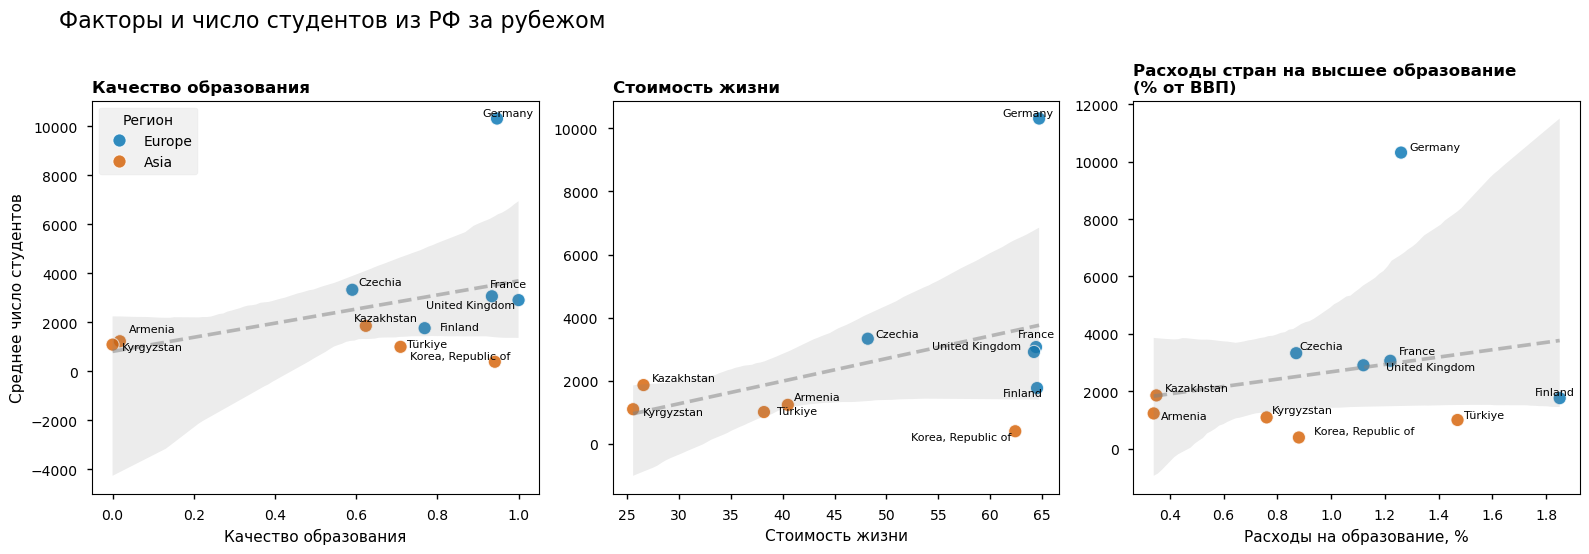

In [7]:
df_agg_reg=df_agg.copy()
df_agg_reg['Регион']={'Germany':'Europe',
                     'Czechia':'Europe',
                      'France':'Europe',
                     'United Kingdom':'Europe',
                     'Finland':'Europe',
                     'Kazakhstan':'Asia',
                     'Armenia':'Asia',
                     'Kyrgyzstan':'Asia',
                     'Türkiye':'Asia',
                     'Korea, Republic of':'Asia'}

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

mpl.style.use('seaborn-v0_8-notebook')

fig, (ax1, ax2, ax3)=plt.subplots(1,3, figsize=(16,5.5))

# Качество образования и число студентов
sns.scatterplot(data=df_agg_reg,
                x='Качество образования_преобр',
                y='Среднее число студентов',
                hue='Регион',
                hue_order=['Europe', 'Asia'],
                palette=['#0072B2', '#D55E00'],
                s=90,
                alpha=0.8,
                ax=ax1)
sns.regplot(data=df_agg_reg,
            x='Качество образования_преобр',
            y='Среднее число студентов',
            scatter=False,
            ax=ax1,
            color='gray',
            line_kws={'linestyle':'--',
                     'alpha':0.5})
texts=[]
for i, country in enumerate(df_agg_reg.index):
    texts.append(ax1.text(df_agg_reg['Качество образования_преобр'].iloc[i],
                          df_agg_reg['Среднее число студентов'].iloc[i],
                          country,
                          fontsize=8))
adjust_text(texts, ax=ax1) 

ax1.set_title('Качество образования', 
              fontsize=12,
              fontweight='bold',
              loc='left')
ax1.set_xlabel('Качество образования')
ax1.set_ylabel('Среднее число студентов')
ax1.legend(title='Регион', loc='upper left', facecolor='lightgray', framealpha=0.3)
ax1.grid(False)

# Стоимость жизни и число студентов
sns.scatterplot(data=df_agg_reg,
                x='Стоимость жизни',
                y='Среднее число студентов',
                hue='Регион',
                hue_order=['Europe', 'Asia'],
                palette=['#0072B2', '#D55E00'],
                s=90,
                alpha=0.8,
                ax=ax2)
sns.regplot(data=df_agg_reg,
            x='Стоимость жизни',
            y='Среднее число студентов',
            scatter=False,
            ax=ax2,
            color='gray',
            line_kws={'linestyle':'--',
                     'alpha':0.5})
texts2=[]
for i, country in enumerate(df_agg_reg.index):
    texts2.append(ax2.text(df_agg_reg['Стоимость жизни'].iloc[i],
                          df_agg_reg['Среднее число студентов'].iloc[i],
                          country,
                          fontsize=8))
adjust_text(texts2, ax=ax2)   

ax2.set_title('Стоимость жизни', 
              fontsize=12,
              fontweight='bold',
              loc='left')
ax2.set_xlabel('Стоимость жизни')
ax2.set_ylabel('')
ax2.legend().remove()
ax2.grid(False)

# Расходы на образование и число студентов
sns.scatterplot(data=df_agg_reg,
                x='Расходы на образование, %',
                y='Среднее число студентов',
                hue='Регион',
                hue_order=['Europe', 'Asia'],
                palette=['#0072B2', '#D55E00'],
                s=90,
                alpha=0.8,
                ax=ax3)
sns.regplot(data=df_agg_reg,
            x='Расходы на образование, %',
            y='Среднее число студентов',
            scatter=False,
            ax=ax3,
            color='gray',
            line_kws={'linestyle':'--',
                     'alpha':0.5})
texts3=[]
for i, country in enumerate(df_agg_reg.index):
    texts3.append(ax3.text(df_agg_reg['Расходы на образование, %'].iloc[i],
                          df_agg_reg['Среднее число студентов'].iloc[i],
                          country,
                          fontsize=8))
adjust_text(texts3, ax=ax3)    

ax3.set_title('Расходы стран на высшее образование\n(% от ВВП)', 
              fontsize=12,
              fontweight='bold',
              loc='left')
ax3.set_xlabel('Расходы на образование, %')
ax3.set_ylabel('')
ax3.legend().remove()
ax3.grid(False)

plt.suptitle('Факторы и число студентов из РФ за рубежом', fontsize=16, ha='left', x=0.04, y=1)

plt.tight_layout()

plt.savefig('../visuals/04_factors_and_students.png', dpi=150, bbox_inches='tight')

plt.show()

## Корреляционный анализ и проверка выбросов

In [8]:
# Корреляция Спирмена по выборке из 10 стран с Германией

corr=df_agg_reg[['Среднее число студентов',
                'Качество образования_преобр',
                'Стоимость жизни',
                'Расходы на образование, %']].corr(method='spearman')
corr.round(2)

,Среднее число студентов,Качество образования_преобр,Стоимость жизни,"Расходы на образование, %"
Среднее число студентов,1.00,0.28,0.53,0.12
Качество образования_преобр,0.28,1.00,0.76,0.59
Стоимость жизни,0.53,0.76,1.00,0.65
"Расходы на образование, %",0.12,0.59,0.65,1.00


In [9]:
# Проверка p-value

from scipy.stats import spearmanr, pearsonr

# Корреляция между числом студентов и качеством образования
corr1, p_value1=spearmanr(df_agg_reg['Среднее число студентов'],
                df_agg_reg['Качество образования_преобр'])
print(f'Корреляция между числом студентов и качеством образования:', 
    f'\nКоэффициент корреляции: {corr1}',
    f'\np-value: {p_value1}' )

# Корреляция между числом студентов и государственными расходами на высшее образование
corr2, p_value2=spearmanr(df_agg_reg['Среднее число студентов'], 
                          df_agg_reg['Расходы на образование, %'])
print(f'\nКорреляция между числом студентов и государственными расходами на высшее образование:', 
    f'\nКоэффициент корреляции: {corr2}',
    f'\np-value: {p_value2}' )

# Корреляция между числом студентов и стоимостью жизни
corr3, p_value3=spearmanr(df_agg_reg['Среднее число студентов'], 
                          df_agg_reg['Стоимость жизни'])
print(f'\nКорреляция между числом студентов и стоимостью жизни:', 
    f'\nКоэффициент корреляции: {corr3}',
    f'\np-value: {p_value3}' )

Корреляция между числом студентов и качеством образования: 
Коэффициент корреляции: 0.28484848484848485 
p-value: 0.42503815489214547

Корреляция между числом студентов и государственными расходами на высшее образование: 
Коэффициент корреляции: 0.11515151515151514 
p-value: 0.7514196523258483

Корреляция между числом студентов и стоимостью жизни: 
Коэффициент корреляции: 0.5272727272727272 
p-value: 0.11730806555020223


In [10]:
# Корреляция по выборке из 9 стран без Германии

df_agg_reg_no_germany=df_agg_reg.drop('Germany')
corr_no_germany=df_agg_reg_no_germany[['Среднее число студентов',
                                       'Качество образования_преобр',
                                       'Стоимость жизни',
                                       'Расходы на образование, %']].corr(method='spearman')
corr_no_germany.round(2)

,Среднее число студентов,Качество образования_преобр,Стоимость жизни,"Расходы на образование, %"
Среднее число студентов,1.00,0.07,0.35,0.00
Качество образования_преобр,0.07,1.00,0.72,0.62
Стоимость жизни,0.35,0.72,1.00,0.65
"Расходы на образование, %",0.00,0.62,0.65,1.00


In [11]:
# Проверка на наличие выбросов

Q1=df_agg_reg['Среднее число студентов'].quantile(0.25)
Q3=df_agg_reg['Среднее число студентов'].quantile(0.75)

IQR=Q3-Q1

outliers=df_agg_reg[(df_agg_reg['Среднее число студентов']<Q1-1.5*IQR) | 
                    (df_agg_reg['Среднее число студентов']>Q3+1.5*IQR)]
outliers  

,Среднее число студентов,Студенты_cv,Качество образования,Качество образования_преобр,"Расходы на образование, %",Стоимость жизни,Регион
Страна,,,,,,,
Germany,10314,0.07,69,0.946895,1.26,64.7,Europe


<Axes: >

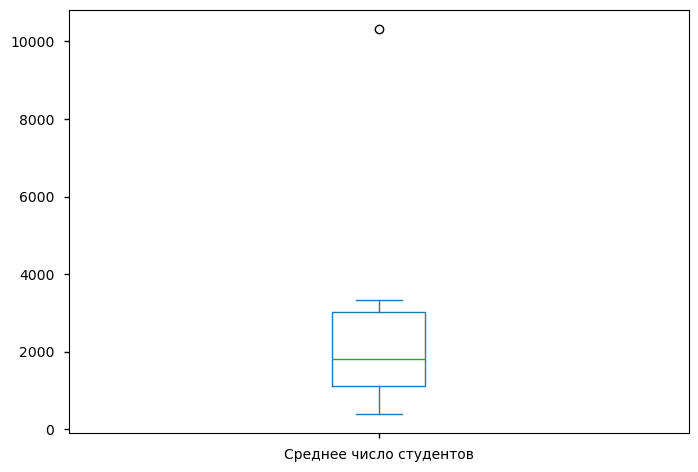

In [12]:
df_agg_reg['Среднее число студентов'].plot.box()

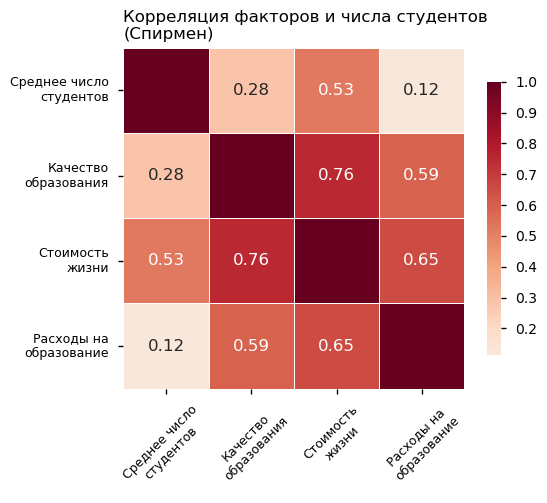

In [13]:
labels=['Среднее число\nстудентов',
       'Качество\nобразования',
       'Стоимость\nжизни',
       'Расходы на\nобразование']

annot_text=corr.round(2).astype(str).replace('1.0','')

plt.figure(figsize=(6,5))

ax=sns.heatmap(corr,
               annot=annot_text,
               fmt='',
               cmap='RdBu_r',
               center=0,
               square=True,
               linewidths=0.5,
               annot_kws={'fontsize':12},
               cbar_kws={'shrink':0.8})

ax.set_title('Корреляция факторов и числа студентов\n(Спирмен)', loc='left')
ax.set_xticklabels(labels, fontsize=9, rotation=45)
ax.set_yticklabels(labels, fontsize=9, rotation=0)

plt.tight_layout()

plt.savefig('../visuals/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')

plt.show()

## Основные результаты:
- Статистика подтверждает уже отмеченную неравномерность распределения российских студентов между странами, при которой небольшое число стран принимает основную долю студентов.
- Германия – наиболее стабильное образовательное направление среди ведущих стран Европы и Азии.
- Между числом студентов из России и такими характеристиками стран, как качество образования, расходы на высшее образование и стоимость жизни, не наблюдается статистически значимой связи.
- Германия значительно выделяется среди других стран по числу студентов и оказывает влияние на результаты корреляционного анализа (корреляция рассчитана как с учетом, так и без учета Германии).
- Поскольку рассмотренные показатели не объясняют распределение российских студентов между странами, необходимо учитывать другие факторы, среди которых сложившие институциональные связи, стоимость и язык обучения, а также внешнеполитические условия.
